<img src="../img/GTK_Logo_Social_Icon.jpg" width=175 align="right" />

# Worksheet 13.3: Agentic Conditional Routing & Tiered Analysis - Answers
## Smart Routing for SOC Efficiency

**Estimated Time**: 45-60 minutes

### Learning Objectives
- Use `add_conditional_edges` to create branching logic in your graph
- Write routing functions that direct emails to different analysis paths
- Build a multi-branch graph where different risk levels get different treatment
- Understand how real SOC triage workflows prioritize analysis resources

### What You'll Build
A tiered analysis pipeline that routes emails based on risk:
```
START → initial_triage → route_by_risk →(high)→ deep_investigation ─┐
                                       →(medium)→ light_review ────├→ compile_report → END
                                       →(low)→ fast_pass ────────┘
```

### Why Tiered Analysis?
Real SOC teams can't spend 10 minutes investigating every email. Tiered analysis mirrors real-world triage: obvious threats get deep investigation, borderline cases get a quick review, and clearly safe emails pass through quickly.

In [1]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

# Verify API key is set
assert os.getenv("ANTHROPIC_API_KEY"), "Please set ANTHROPIC_API_KEY in your .env file"
print("Environment loaded successfully!")

Environment loaded successfully!


In [3]:
import json
from typing import Optional

from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

import sys
sys.path.insert(0, "..")
from utils.email_loader import load_emails, format_email_for_analysis
from utils.mock_tools import check_url_reputation, check_sender_reputation, check_email_authentication
from utils.display_helpers import display_verdict, display_batch_results, display_investigation_report, display_graph_mermaid

In [4]:
emails = load_emails(small=False)
print(f"Loaded {len(emails)} emails for tiered analysis")

Loaded 50 emails for tiered analysis


---
## Step 1: Define Extended State

In Labs 1 and 2, our state carried just the email data and a classification. For tiered analysis,
we need the state to carry **more context** as the email flows through different branches:

| Field | Type | Purpose |
|-------|------|---------|
| `email` | `dict` | The raw email data from our dataset |
| `email_text` | `str` | Formatted email string for the LLM to read |
| `risk_level` | `str` | Triage result: "high", "medium", or "low" |
| `classification` | `dict` | Structured classification from the analysis node |
| `investigation_notes` | `list[str]` | Evidence collected during analysis (enrichment) |
| `final_report` | `dict` | Structured final report assembled at the end |

The key new idea is **state enrichment**: each node adds information to the state, building up
a richer picture as the email moves through the pipeline. The `investigation_notes` list grows
as nodes append their findings.

In [5]:
class TriageState(TypedDict):
    email: dict
    email_text: str
    risk_level: Optional[str]          # "high", "medium", or "low"
    classification: Optional[dict]
    investigation_notes: list[str]     # Evidence collected during analysis
    final_report: Optional[dict]       # Structured final report

In [6]:
class InitialTriage(BaseModel):
    """Quick triage assessment."""
    risk_level: str = Field(description="Risk level: 'high', 'medium', or 'low'")
    quick_assessment: str = Field(description="One-sentence assessment of why this risk level was chosen")
    key_red_flags: list[str] = Field(description="List of red flags noticed", default_factory=list)


class FinalClassification(BaseModel):
    verdict: str = Field(description="Classification: 'phishing', 'suspicious', or 'legitimate'")
    confidence: float = Field(ge=0.0, le=1.0)
    reasoning: str
    indicators: list[str] = Field(default_factory=list)

In [7]:
llm = ChatAnthropic(model="claude-opus-4-8", max_tokens=4096)
triage_llm = llm.with_structured_output(InitialTriage)
classification_llm = llm.with_structured_output(FinalClassification)

---
## Step 2: Initial Triage Node

The first node in our pipeline is a **fast, surface-level assessment**. It uses the LLM with
structured output to quickly categorize emails as high, medium, or low risk.

Critically, this node does **no tool calls** -- no URL checks, no sender lookups, no auth
verification. It relies entirely on the LLM's ability to spot red flags from the email text
alone. This keeps triage fast and cheap.

Think of it like a SOC analyst glancing at an email for 5 seconds: they don't run it through
every scanner, they just use their experience to decide how much attention it deserves.

In [8]:
def initial_triage(state: TriageState) -> dict:
    """Quick triage: assess risk level without using any tools."""
    email_text = format_email_for_analysis(state["email"])

    prompt = f"""You are a SOC analyst doing initial triage on an incoming email.
Quickly assess the risk level based on surface indicators ONLY (no tool lookups needed).

Rules for risk levels:
- HIGH: Obvious phishing indicators (spoofed domains, urgency + credential requests, suspicious attachments like .exe/.xlsm/.docm, failed auth headers, BEC patterns)
- MEDIUM: Some suspicious elements but could be legitimate (unknown senders, marketing emails with links, mixed auth results)
- LOW: Clearly legitimate (internal senders with passing auth, known safe domains, routine business communications)

Email:
{email_text}"""

    result = triage_llm.invoke(prompt)
    return {
        "email_text": email_text,
        "risk_level": result.risk_level,
        "investigation_notes": [f"Initial triage: {result.quick_assessment}"] +
                              [f"Red flag: {rf}" for rf in result.key_red_flags],
    }

---
## Step 3: The Routing Function

This is the key new concept in Lab 3: **conditional edges**.

A routing function is a plain Python function that:
1. Takes the current graph state as input
2. Returns a **string** that names which node to go to next

When you call `add_conditional_edges()`, you provide:
- The **source node** (where the routing happens after)
- The **routing function** (decides which path)
- A **mapping dict** that maps return values to node names

```python
workflow.add_conditional_edges(
    "initial_triage",      # After this node...
    route_by_risk,          # ...call this function...
    {                       # ...and map its return value to a node:
        "deep_investigation": "deep_investigation",
        "light_review": "light_review",
        "fast_pass": "fast_pass",
    }
)
```

The routing function itself is simple -- it just reads a value from state and returns a string.
All the intelligence is in the triage node that *sets* that value.

In [9]:
def route_by_risk(state: TriageState) -> str:
    """Route to different analysis paths based on risk level."""
    risk = state["risk_level"].lower()
    if risk == "high":
        return "deep_investigation"
    elif risk == "medium":
        return "light_review"
    else:
        return "fast_pass"

---
## Step 4: Three Analysis Paths

Now we define the three analysis nodes -- one for each risk level. They differ in how much
work they do:

| Path | Risk Level | Tools Used | LLM Calls | Purpose |
|------|-----------|------------|-----------|----------|
| `deep_investigation` | HIGH | URL + Sender + Auth | Yes (classify with evidence) | Full forensic analysis |
| `light_review` | MEDIUM | Auth only | Yes (classify with auth result) | Quick sanity check |
| `fast_pass` | LOW | None | No | Auto-approve, skip analysis |

Notice how `deep_investigation` calls tools **directly** using `.invoke()` rather than through
a LangGraph ToolNode. This is intentional -- we're orchestrating the tool calls ourselves in a
predetermined sequence, not letting the LLM decide which tools to call. This gives us more
control and predictability for high-risk emails where we always want the full battery of checks.

In [10]:
def deep_investigation(state: TriageState) -> dict:
    """Full investigation for high-risk emails: check URLs, sender, and authentication."""
    email = state["email"]
    notes = list(state["investigation_notes"])
    notes.append("--- Deep Investigation ---")

    # Check all URLs
    for url in email.get("urls", []):
        result = check_url_reputation.invoke({"url": url})
        notes.append(f"URL Check: {result}")

    # Check sender
    result = check_sender_reputation.invoke({"email_address": email["from_address"]})
    notes.append(f"Sender Check: {result}")

    # Check authentication
    headers = email.get("headers", {})
    result = check_email_authentication.invoke({
        "from_address": email["from_address"],
        "spf": headers.get("spf", "none"),
        "dkim": headers.get("dkim", "none"),
        "dmarc": headers.get("dmarc", "none"),
    })
    notes.append(f"Auth Check: {result}")

    # Now classify with all evidence
    evidence = "\n".join(notes)
    prompt = f"""Based on the following investigation evidence, classify this email.

Email:
{state['email_text']}

Investigation Evidence:
{evidence}

Provide your final classification."""

    result = classification_llm.invoke(prompt)
    return {
        "investigation_notes": notes,
        "classification": result.model_dump(),
    }

In [11]:
def light_review(state: TriageState) -> dict:
    """Light review for medium-risk emails: check auth headers only."""
    email = state["email"]
    notes = list(state["investigation_notes"])
    notes.append("--- Light Review ---")

    # Only check authentication
    headers = email.get("headers", {})
    result = check_email_authentication.invoke({
        "from_address": email["from_address"],
        "spf": headers.get("spf", "none"),
        "dkim": headers.get("dkim", "none"),
        "dmarc": headers.get("dmarc", "none"),
    })
    notes.append(f"Auth Check: {result}")

    prompt = f"""Based on the email and authentication check, classify this email.

Email:
{state['email_text']}

Authentication Result:
{result}

Provide your final classification."""

    classification = classification_llm.invoke(prompt)
    return {
        "investigation_notes": notes,
        "classification": classification.model_dump(),
    }

In [12]:
def fast_pass(state: TriageState) -> dict:
    """Fast pass for low-risk emails: minimal analysis, auto-approve."""
    notes = list(state["investigation_notes"])
    notes.append("--- Fast Pass (Low Risk) ---")
    notes.append("Auto-approved: email passed initial triage with low risk indicators")

    return {
        "investigation_notes": notes,
        "classification": {
            "verdict": "legitimate",
            "confidence": 0.85,
            "reasoning": "Email passed initial triage with no significant risk indicators. Authentication headers pass and sender appears legitimate.",
            "indicators": ["Passed initial triage", "No red flags detected"],
        },
    }

In [13]:
def compile_report(state: TriageState) -> dict:
    """Compile the final investigation report."""
    email = state["email"]
    c = state["classification"]

    report = {
        "email_id": email["id"],
        "subject": email["subject"],
        "from": f"{email['from_display_name']} <{email['from_address']}>",
        "risk_level": state["risk_level"],
        "verdict": c["verdict"],
        "confidence": c["confidence"],
        "reasoning": c["reasoning"],
        "evidence": state["investigation_notes"],
        "recommendation": (
            "BLOCK and alert security team" if c["verdict"] == "phishing"
            else "QUARANTINE for manual review" if c["verdict"] == "suspicious"
            else "ALLOW delivery"
        ),
    }
    return {"final_report": report}

---
## Step 5: Build the Multi-Branch Graph

Now we assemble everything into a single graph. The key new API is `add_conditional_edges`,
which creates a branching point in the graph:

1. **Linear entry**: `START` → `initial_triage` (every email starts here)
2. **Conditional branch**: `initial_triage` → `route_by_risk` → one of three paths
3. **Convergence**: all three paths → `compile_report` → `END`

This pattern -- fan-out then fan-in -- is extremely common in production pipelines. Different
inputs get different treatment, but they all converge at a common output stage.

In [14]:
workflow = StateGraph(TriageState)

# Add all nodes
workflow.add_node("initial_triage", initial_triage)
workflow.add_node("deep_investigation", deep_investigation)
workflow.add_node("light_review", light_review)
workflow.add_node("fast_pass", fast_pass)
workflow.add_node("compile_report", compile_report)

# Linear entry
workflow.add_edge(START, "initial_triage")

# Conditional routing based on risk level
workflow.add_conditional_edges(
    "initial_triage",
    route_by_risk,
    {
        "deep_investigation": "deep_investigation",
        "light_review": "light_review",
        "fast_pass": "fast_pass",
    },
)

# All paths converge at compile_report
workflow.add_edge("deep_investigation", "compile_report")
workflow.add_edge("light_review", "compile_report")
workflow.add_edge("fast_pass", "compile_report")
workflow.add_edge("compile_report", END)

graph = workflow.compile()
print("Tiered analysis graph compiled!")

Tiered analysis graph compiled!


### Lab 3: Tiered Analysis Pipeline

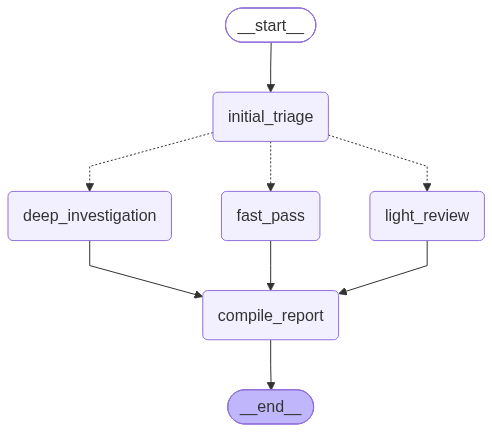

In [15]:
display_graph_mermaid(graph, "Lab 3: Tiered Analysis Pipeline")

---
## Step 6: Test with Selected Emails

Let's test with a handful of representative emails to see how the routing works. We pick
emails that we expect to route to different risk levels, so we can verify all three paths
are functioning correctly.

In [16]:
# Test with representative emails from each category

test_ids = ["EMAIL-001", "EMAIL-006", "EMAIL-026", "EMAIL-035", "EMAIL-049"]
test_set = [e for e in emails if e["id"] in test_ids]

for email in test_set:
    result = graph.invoke({
        "email": email,
        "email_text": "",
        "risk_level": None,
        "classification": None,
        "investigation_notes": [],
        "final_report": None,
    })

    report = result["final_report"]
    print(f"\n{email['id']}: Routed to {report['risk_level'].upper()} path")
    display_investigation_report(report)


EMAIL-001: Routed to HIGH path


Verdict:,PHISHING
Confidence:,99%
Risk Level:,HIGH



EMAIL-026: Routed to LOW path


Verdict:,LEGITIMATE
Confidence:,85%
Risk Level:,LOW



EMAIL-006: Routed to HIGH path


Verdict:,PHISHING
Confidence:,99%
Risk Level:,HIGH



EMAIL-035: Routed to LOW path


Verdict:,LEGITIMATE
Confidence:,85%
Risk Level:,LOW



EMAIL-049: Routed to MEDIUM path


Verdict:,SUSPICIOUS
Confidence:,78%
Risk Level:,MEDIUM


---
## Step 7: Process Full Dataset & Analyze Routing Distribution

Now let's run all 50 emails through the pipeline and see how the routing distributes across
the three paths. In a well-tuned system, you'd expect:
- **HIGH**: ~20-30% of emails (the obvious threats)
- **MEDIUM**: ~20-30% (the ambiguous cases)
- **LOW**: ~40-60% (the clearly safe majority)

This distribution matters for SOC capacity planning. If too many emails route to HIGH, your
deep investigation pipeline becomes a bottleneck. If too few route to HIGH, you might be
missing threats.

In [19]:
# Process all 50 emails and show routing distribution
routing_stats = {"high": 0, "medium": 0, "low": 0}
all_results = []

for email in emails:
    print(f"Processing email {email['id']}...")
    result = graph.invoke({
        "email": email,
        "email_text": "",
        "risk_level": None,
        "classification": None,
        "investigation_notes": [],
        "final_report": None,
    })
    report = result["final_report"]
    routing_stats[report["risk_level"].lower()] += 1
    all_results.append({
        "email_id": email["id"],
        "verdict": report["verdict"],
        "confidence": report["confidence"],
        "ground_truth": email["ground_truth"],
    })

print("Routing Distribution:")
for level, count in routing_stats.items():
    print(f"  {level.upper()}: {count} emails")

display_batch_results(all_results)

Processing email EMAIL-001...
Processing email EMAIL-026...
Processing email EMAIL-002...
Processing email EMAIL-027...
Processing email EMAIL-003...
Processing email EMAIL-028...
Processing email EMAIL-004...
Processing email EMAIL-029...
Processing email EMAIL-005...
Processing email EMAIL-030...
Processing email EMAIL-006...
Processing email EMAIL-031...
Processing email EMAIL-007...
Processing email EMAIL-032...
Processing email EMAIL-008...
Processing email EMAIL-033...
Processing email EMAIL-009...
Processing email EMAIL-034...
Processing email EMAIL-010...
Processing email EMAIL-035...
Processing email EMAIL-011...
Processing email EMAIL-036...
Processing email EMAIL-012...
Processing email EMAIL-037...
Processing email EMAIL-013...
Processing email EMAIL-038...
Processing email EMAIL-014...
Processing email EMAIL-039...
Processing email EMAIL-015...
Processing email EMAIL-040...
Processing email EMAIL-016...
Processing email EMAIL-041...
Processing email EMAIL-017...
Processing

Email ID,Verdict,Confidence,Ground Truth,Match
EMAIL-001,PHISHING,99%,phishing,✅
EMAIL-026,LEGITIMATE,85%,legitimate,✅
EMAIL-002,PHISHING,98%,phishing,✅
EMAIL-027,LEGITIMATE,85%,legitimate,✅
EMAIL-003,PHISHING,99%,phishing,✅
EMAIL-028,LEGITIMATE,85%,legitimate,✅
EMAIL-004,PHISHING,98%,phishing,✅
EMAIL-029,LEGITIMATE,85%,legitimate,✅
EMAIL-005,PHISHING,97%,phishing,✅
EMAIL-030,LEGITIMATE,85%,legitimate,✅


---
## Checkpoint Checklist

- [ ] Graph compiles with three conditional branches
- [ ] Mermaid diagram shows: initial_triage → (high/medium/low) → three paths → compile_report → END
- [ ] High-risk emails get full tool-based investigation (URL + sender + auth checks)
- [ ] Medium-risk emails get authentication check only
- [ ] Low-risk emails get fast-tracked with auto-approval
- [ ] All paths converge at compile_report and produce structured reports
- [ ] Most phishing emails route to HIGH, most legitimate to LOW

## What's Next?

In **Lab 4**, we'll add human-in-the-loop review. Ambiguous cases will pause the graph and wait for a human analyst to approve, override, or escalate the verdict before finalizing.